# CS 584-A: Natural Language Processing - Homework 1
**Sentiment analysis on Amazon product reviews**

**Student:** Mandar Sanju Bavdane &nbsp;&nbsp; **CWID:** 20041513

---
### Task definition (stated up front, as the assignment requires)
* **Problem solved:** **binary** sentiment classification (positive vs. negative) from free-text reviews.
* **How the class labels were prepared** (from the 1-5 `overall` rating):
  * rating **4 or 5 -> positive (label 1)**
  * rating **1 or 2 -> negative (label 0)**
  * rating **3 (neutral) -> discarded**
* **Pipeline:** load -> preprocess -> 80/10/10 split -> statistics -> count-based word vectors (co-occurrence + SVD) -> GloVe word vectors -> review embeddings (average of word vectors) -> Logistic Regression (L2) and a Neural Network -> evaluation on the test set.
* **Note on dataset size:** the handout says 4,195 products; the file provided on Canvas actually contains **4,915 rows**. All numbers in this notebook are computed from the file as provided.

## 0. Setup
This cell imports every library used in the notebook and fixes the random seeds so that every run produces the same numbers.

In [23]:
import os, re, string, random, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, log_loss, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)


SEED = 42                      # one global seed for reproducible results
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")     # consistent plot style
plt.rcParams["figure.dpi"] = 110

nltk.download("stopwords", quiet=True)   # one-off download of the stop-word list
print("Setup complete.")

Setup complete.


# Task 1: Extracting features
## 1. Data preparation


### 1) Data preprocessing

**Step A - load the data.** We read the CSV file, look at its size and check for the missing values.

In [24]:
df_raw = pd.read_csv('/content/amazon_reviews.csv') # Load data
print("Shape of raw data:",df_raw.shape)
print("\nMissing values per column:\n",df_raw.isna().sum())
print("\n\nFirst five rows:")
df_raw.head()

Shape of raw data: (4915, 2)

Missing values per column:
 overall       0
reviewText    1
dtype: int64


First five rows:


,overall,reviewText
0,4,No issues.
1,5,"Purchased this for my device, it worked as adv..."
2,4,it works as expected. I should have sprung for...
3,5,This think has worked out great.Had a diff. br...
4,5,"Bought it with Retail Packaging, arrived legit..."


**Step B - clean and label.**
* One review has no text (`NaN`), so it cannot be used and should be dropped!
* The original 5-class rating distribution is plotted first and we can clearly see that it is **strongly imbalanced toward 5 stars**

* Binary labels are created: 4-5 -> 1(+ve), 1-2 -> 0(-ve), 3 -> dropped.

Rows after dropping missing text: 4914 (removed 1)



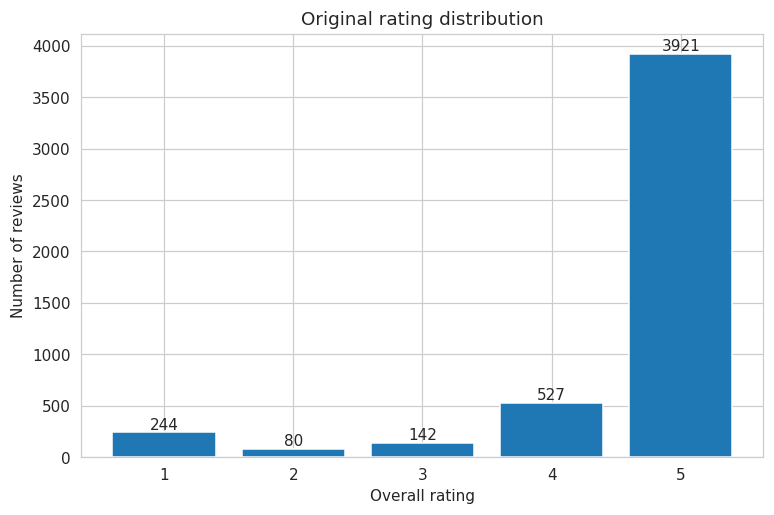


Neutral (3-star) reviews discarded: 142
Binary label counts(0(-ve), 1(+ve):
label
0     324
1    4448
Name: count, dtype: int64


In [25]:
# 1) drop rows without review text
df = df_raw.dropna(subset=["reviewText"]).copy()
print(f"Rows after dropping missing text: {len(df)} (removed {len(df_raw) - len(df)})\n")

# 2) Plot the original (5 star) ratings
rating_counts = df["overall"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values)
ax.bar_label(bars)
ax.set_xlabel("Overall rating"); ax.set_ylabel("Number of reviews")
ax.set_title("Original rating distribution")
plt.show()

# 3) Binary Labels: 4,5 -> 1 (positive); 1,2 -> 0 (negative); 3 (neutral) -> discarded
n_before = len(df)
df = df[df["overall"] != 3].copy()
df["label"] = (df["overall"] >= 4).astype(int)
print(f"\nNeutral (3-star) reviews discarded: {n_before - len(df)}")
print("Binary label counts(0(-ve), 1(+ve):")
print(df["label"].value_counts().sort_index())

**Step C - Text Preprocessing.


1. **lowercase** everything
2. **remove punctuation** - apostrophes are deleted (eg. `don't` -> `dont`),
- every other punctuation mark is replaced by a space (eg. `well-made` -> `well made`);
3. **remove numbers**
4. **tokenize** by whitespace
5. **remove stop-words** using NLTK's English list

`Note`: NLTK's list also removes negations such as *not* / *no*

In [26]:
STOPWORDS = set(stopwords.words("english"))
STOPWORDS |= {w.replace("'", "") for w in STOPWORDS}          # e.g. "don't" -> "dont"

PUNCT_TO_SPACE = str.maketrans({c: " " for c in string.punctuation if c != "'"})

def preprocess(text):
    """Raw review string -> list of cleaned tokens."""
    text = text.lower()                                        # lowercase
    text = text.replace("'", "").replace("\u2019", "")         # curly apostrophes
    text = text.translate(PUNCT_TO_SPACE)                      # remove punctuation
    text = re.sub(r"\d+", " ", text)                           # remove numbers
    tokens = text.split()                                      # tokenize on whitespace
    return [t for t in tokens if t not in STOPWORDS]           # remove stopwords

df["tokens"] = df["reviewText"].apply(preprocess)

# Before & After
example = df.iloc[3]
print("RAW   :", example["reviewText"][:200])
print("TOKENS:", example["tokens"][:25])

# Dropping the reviews that became empty after cleaning
n_empty = (df["tokens"].str.len() == 0).sum()
df = df[df["tokens"].str.len() > 0].reset_index(drop=True)
print(f"\nEmpty reviews removed: {n_empty}   |   Final number of reviews: {len(df)}")

RAW   : This think has worked out great.Had a diff. bran 64gb card and if went south after 3 months.This one has held up pretty well since I had my S3, now on my Note3.*** update 3/21/14I've had this for a fe
TOKENS: ['think', 'worked', 'great', 'diff', 'bran', 'gb', 'card', 'went', 'south', 'months', 'one', 'held', 'pretty', 'since', 'note', 'update', 'months', 'zero', 'issues', 'since', 'transferred', 'note', 'note', 'card', 'reliable']

Empty reviews removed: 0   |   Final number of reviews: 4772


### 2) Data split
The data is split **80 % / 10 % / 10 %** into `train/validation(dev)/test`.

Two successive calls to `train_test_split` are used: first 80/20, then the 20 % is halved into validation and test.

In [27]:
train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)
dev_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

for name, part in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    print(f"{name:5s}: {len(part):5d} reviews --> ({len(part)/len(df):.1%})")

train:  3817 reviews --> (80.0%)
dev  :   477 reviews --> (10.0%)
test :   478 reviews --> (10.0%)


### 3) Data statistics
What are we reporting per split:

number of samples,

number of positive / negative reviews,

and the **minimum / average / median / maximum number of tokens per review** (after preprocessing).

,Samples,Positive,Negative,min_tokens,avg_tokens,median_tokens,max_tokens
Split,,,,,,,
Train,3817,3558,259,1,25.16,16,775
Dev,477,445,32,1,23.10,16,226
Test,478,445,33,1,23.39,16,141
All,4772,4448,324,1,24.78,16,775



Total tokens: 118,228 | Vocabulary size (distinct tokens): 7,402


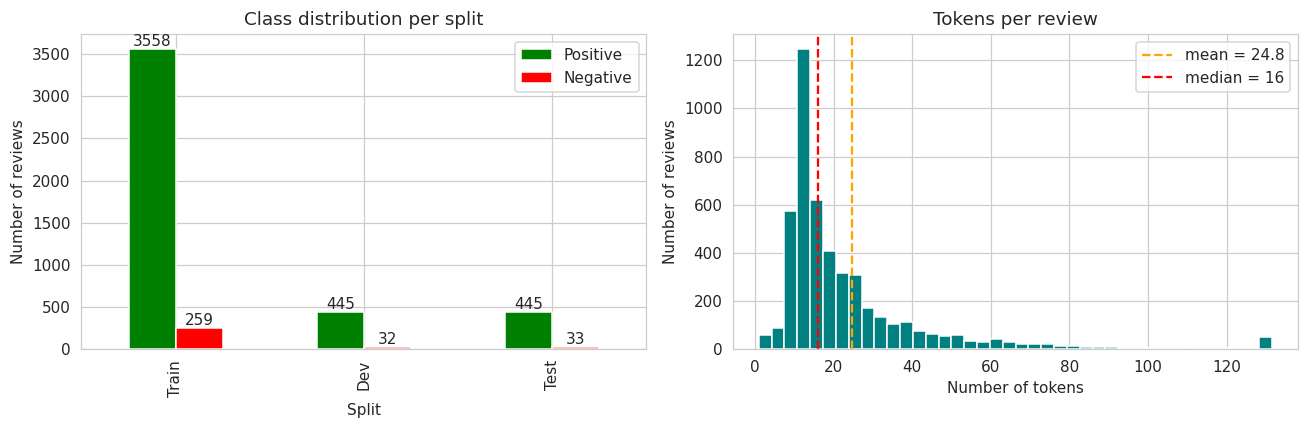

In [28]:
rows = []
for name, part in [("Train", train_df), ("Dev", dev_df), ("Test", test_df), ("All", df)]:
    lens = part["tokens"].str.len()
    rows.append({"Split": name,
                 "Samples": len(part),
                 "Positive": int((part["label"] == 1).sum()),
                 "Negative": int((part["label"] == 0).sum()),
                 "min_tokens": int(lens.min()),
                 "avg_tokens": round(lens.mean(), 2),
                 "median_tokens": int(lens.median()),
                 "max_tokens": int(lens.max())})
stats_df = pd.DataFrame(rows).set_index("Split")
display(stats_df)

all_tokens = [t for toks in df["tokens"] for t in toks]
print(f"\nTotal tokens: {len(all_tokens):,} | Vocabulary size (distinct tokens): {len(set(all_tokens)):,}")



fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# (a) class counts per split
plot_df = stats_df.loc[["Train", "Dev", "Test"], ["Positive", "Negative"]]
plot_df.plot(kind="bar", ax=axes[0], color=["green", "red"])
for c in axes[0].containers: axes[0].bar_label(c)
axes[0].set_title("Class distribution per split")
axes[0].set_ylabel("Number of reviews")


# (b) review length distribution (clipped at the 99th percentile so the long tail does not squash the plot)
lens_all = df["tokens"].str.len()
axes[1].hist(lens_all.clip(upper=lens_all.quantile(0.99)), bins=40, color="teal")
axes[1].axvline(lens_all.mean(), color="orange", ls="--", label=f"mean = {lens_all.mean():.1f}")
axes[1].axvline(lens_all.median(), color="red", ls="--", label=f"median = {lens_all.median():.0f}")
axes[1].set_title("Tokens per review")
axes[1].set_xlabel("Number of tokens")
axes[1].set_ylabel("Number of reviews")
axes[1].legend()
plt.tight_layout(); plt.show()

# Data Statistics & Analytical Implications

## Dataset Composition
* **Size & Splits:** 4,772 reviews after cleaning structured into a stratified **80/10/10%** distribution (**3,817** train / **477** dev / **478** test) which was followed by the removal of 1 empty and 142 neutral ratings
* **Class Imbalance:** Highly skewed toward positive sentiment (**93.2%** positive, **6.8%** negative). Stratification precisely preserved this distribution across all splits which ensured architectural comparability


## Modeling & Evaluation Consequences

### 1. Evaluation Metrics
Standard accuracy is a compromised metric; a zero-rule baseline predicting only the majority class yields **93.1% test accuracy**. Evaluation must prioritize Precision, Recall, F1 and AUC

### 2. Statistical Power
The validation and test partitions contain only **32 and 33 negative reviews**.
Therefore, Minority class metrics will be highly volatile which may cause negative recall of ~3% on a single misclassification shift.



## 2. Representation of Texts: Word Vectors
### 1) Count based word vectors with a co-occurrence matrix


**a) `get_vacab(corpus)`** returns `corpus_words`: the sorted list of all distinct words.

In [29]:
def get_vacab(corpus):
    """Return the sorted list of all distinct words in the corpus.

    corpus: list of reviews, each review a list of tokens.
    """
    # Nested list comprehension flattens the corpus
    corpus_words = sorted(set([word for review in corpus for word in review])) # used sorted function for sorting corpus_words
    return corpus_words

# Thi is quick unit test on the toy corpus which is taken from lec slides
toy_corpus = [["i", "like", "deep", "learning"],
              ["i", "like", "nlp"],
              ["i", "enjoy", "flying"]]
print("Toy vocabulary:", get_vacab(toy_corpus))

Toy vocabulary: ['deep', 'enjoy', 'flying', 'i', 'learning', 'like', 'nlp']


**b) `compute_co_occurrence_matrix(corpus, window_size=4)`** (5 pts) returns `M` and `word2index`.


* `word2index` maps each word of the vocabulary to a row/column index
* `M[i, j]` counts how many times word *j* appears within `window_size` positions **before or after** word *i* (the centre word)
* Did the sanity check on toy dataset for cross verification

In [30]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """Build the symmetric word-word co-occurrence count matrix.

    Returns
    -------
    M          : np.ndarray (V, V)  co-occurrence counts
    word2index : dict               word -> row/column index in M
    """
    corpus_words = get_vacab(corpus)                                   # Sorted Vocab (part a)
    word2index = {w: i for i, w in enumerate(corpus_words)}            # Word -> Index
    V = len(corpus_words)
    M = np.zeros((V, V), dtype=np.float32)                             # V x V matrix of zeros

    for review in corpus:                                              # Process each review separately
        idx = [word2index[w] for w in review]                          # Review as a list of indices
        n = len(idx)
        for pos, center in enumerate(idx):                             # Every token is the centre word once
            lo = max(0, pos - window_size)                             # Left edge of the window
            hi = min(n, pos + window_size + 1)                         # Right edge of the window
            for j in range(lo, hi):
                if j != pos:
                    M[center, idx[j]] += 1
    return M, word2index


# Unit test of toy dataset
M_toy, w2i_toy = compute_co_occurrence_matrix(toy_corpus, window_size=1)
toy_df = pd.DataFrame(M_toy.astype(int), index=sorted(w2i_toy, key=w2i_toy.get), columns=sorted(w2i_toy, key=w2i_toy.get))
display(toy_df)
assert toy_df.loc["i", "like"] == 2 and toy_df.loc["i", "enjoy"] == 1 and toy_df.loc["deep", "learning"] == 1
assert np.allclose(M_toy, M_toy.T), "co-occurrence matrix must be symmetric"
print("Toy test passed: matrix matches the lecture example and is symmetric.")

,deep,enjoy,flying,i,learning,like,nlp
deep,0,0,0,0,1,1,0
enjoy,0,0,1,1,0,0,0
flying,0,1,0,0,0,0,0
i,0,1,0,0,0,2,0
learning,1,0,0,0,0,0,0
like,1,0,0,2,0,0,1
nlp,0,0,0,0,0,1,0


Toy test passed: matrix matches the lecture example and is symmetric.


In [31]:
corpus = df["tokens"].tolist()
corpus_words = get_vacab(corpus)
M_co, word2index_co = compute_co_occurrence_matrix(corpus, window_size=4)

print("Vocabulary size:", len(corpus_words))
print("Co-occurrence matrix shape:", M_co.shape)
print("Non-zero entries: %.2f%%" % (100 * np.count_nonzero(M_co) / M_co.size)) # Here 75% of non-zero entries tell us that matrix is very sparse

Vocabulary size: 7402
Co-occurrence matrix shape: (7402, 7402)
Non-zero entries: 0.75%


**c) `reduce_to_k_dim(M, k=2)`** Performing dimensionality reduction with `sklearn.decomposition.TruncatedSVD` (`n_iter = 10`).

`fit_transform` keeps the top-*k* singular components and returns `U_k * Sigma_k`,  

The same function is reused later with `k=128`.

In [32]:
def reduce_to_k_dim(M, k=2):
    """Truncated-SVD dimensionality reduction.

    M : np.ndarray (n_words, n_features)
    k : number of components to keep
    Returns M_reduced : np.ndarray (n_words, k)
    """
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=SEED)   # n_iter=10
    M_reduced = svd.fit_transform(M)                                    # top-k components -> k-dim embeddings
    print(f"Reduced {M.shape} -> {M_reduced.shape} | variance retained: {svd.explained_variance_ratio_.sum():.2%}")
    return M_reduced

M_co_2d = reduce_to_k_dim(M_co, k=2)

Reduced (7402, 7402) -> (7402, 2) | variance retained: 73.98%


**d) `plot_embeddings(M_reduced, word2index, words_to_plot)`** (5 pts) draws a scatter plot of the 2-D embeddings of the requested words and labels each point. Words that are not in `word2index` are skipped with a warning. We call it for the ten words required by the handout.

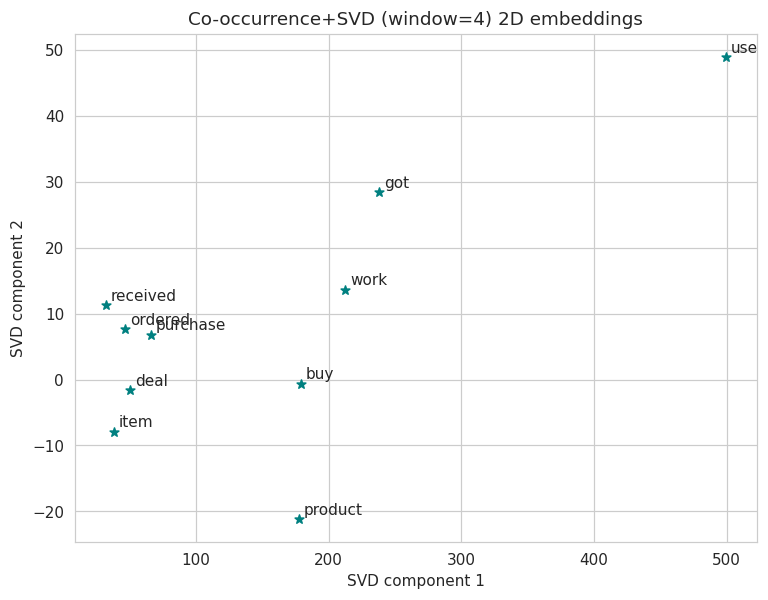

In [33]:
def plot_embeddings(M_reduced, word2index, words_to_plot, title='None'):
    # Scatter plot of 2D embeddings for the words in words_to_plot
    fig, ax = plt.subplots(figsize=(8, 6))
    for word in words_to_plot:
        if word not in word2index:                                      # Guard: word missing from the vocabulary
            print(f"Warning: '{word}' not in word2index - skipped")
            continue
        x, y = M_reduced[word2index[word]]                              # 2-D coordinates of this word
        ax.scatter(x, y, marker="*", color="teal")                    # Scatter plot
        ax.annotate(word, (x, y), textcoords="offset points", xytext=(3,3), fontsize=10)   # Its label
    ax.set_xlabel("SVD component 1")
    ax.set_ylabel("SVD component 2")
    if title: ax.set_title(title)
    plt.show()

words_to_plot = ["purchase", "buy", "work", "got", "ordered", "received", "product", "item", "deal", "use"]
plot_embeddings(M_co_2d, word2index_co, words_to_plot, title="Co-occurrence+SVD (window=4) 2D embeddings")

### 2) Prediction-based word vectors from GloVe
**a) Load GloVe**. We use the provided `load_embedding_model()` , it downloads `glove-wiki-gigaword-200` (400,000 words, 200 dimensions, pre-trained on Wikipedia + Gigaword) through `gensim`.

In [34]:

def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each lengh 200
    """

    %pip install gensim
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

# -----------------------------------
# Run Cell to Load Word Vectors
# Note: This will take a couple minutes
# -----------------------------------
wv_from_bin = load_embedding_model()

Loaded vocab size 400000


**b) Select the GloVe vectors of our vocabulary**.

It builds a matrix `M` containing (1) 10,000 randomly chosen GloVe words (fixed seed 225) and (2) **every word of our review vocabulary** (`required_words = corpus_words` from part 1a) that exists in GloVe.

Review words absent from GloVe (typos, brand names) are skipped. `word2ind` maps word -> row of `M`.

In [35]:
# Run the cell with the exact code given in the assignment
def get_matrix_of_vectors(wv_from_bin, required_words):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
            required_words: words from OUR corpus that must be in the matrix
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    words = words[:10000]
    words_set = set(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words_set:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind


M_glove, word2ind_glove = get_matrix_of_vectors(wv_from_bin, corpus_words)
in_glove = sum(w in word2ind_glove for w in corpus_words)
print("GloVe matrix shape:", M_glove.shape)
print(f"Review vocabulary words found in GloVe: {in_glove} / {len(corpus_words)} ({in_glove/len(corpus_words):.1%})")

Shuffling words ...
Putting 10000 words into word2ind and matrix M...
Done.
GloVe matrix shape: (16267, 200)
Review vocabulary words found in GloVe: 6412 / 7402 (86.6%)


**c) Reduce the GloVe vectors to 2 dimensions** with the `reduce_to_k_dim()` function(200 -> 2 dimensions).

In [36]:
M_glove_2d = reduce_to_k_dim(M_glove, k=2)

Reduced (16267, 200) -> (16267, 2) | variance retained: 12.41%


**d) Plot and compare**

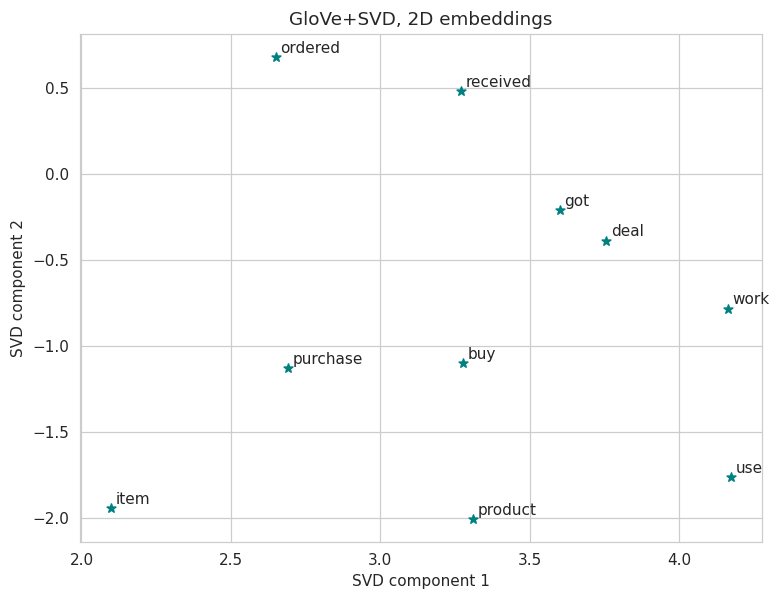

,co-occurrence (raw counts),GloVe (200-d)
pair,,
buy - purchase,0.808,0.814
product - item,0.819,0.434
ordered - received,0.758,0.409
work - use,0.872,0.584
buy - deal,0.668,0.557
got - received,0.757,0.549


In [37]:
plot_embeddings(M_glove_2d, word2ind_glove, words_to_plot, title="GloVe+SVD, 2D embeddings")


def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

pairs = [("buy", "purchase"), ("product", "item"), ("ordered", "received"), ("work", "use"), ("buy", "deal"), ("got", "received")]
rows = []
for a, b in pairs:
    rows.append({"pair": f"{a} - {b}",
                 "co-occurrence (raw counts)": round(cos(M_co[word2index_co[a]], M_co[word2index_co[b]]), 3),
                 "GloVe (200-d)": round(cos(M_glove[word2ind_glove[a]], M_glove[word2ind_glove[b]]), 3)})
display(pd.DataFrame(rows).set_index("pair"))

### **Comparison of the Two Plots (Count Based vs. GloVe)**

* The co-occurrence plot is mainly driven by **word frequency** while on the other hand GloVe captures **semantic similarity and usage** more effectively. Words such as *ordered* and *received*, *buy* and *purchase*, *product* and *item* show more meaningful groupings in the GloVe plot.


* The co-occurrence matrix is sparse (only 0.75% non-zero entries) and built from a small corpus of 118k tokens. In contrast, **pre-trained GloVe** learns from around 6 billion tokensw which produces denser and more reliable semantic representations.

* Limitations of Glove: it misses 13.4% of word types, mainly typos, brand names and model numbers, but still covers 98.5% of all tokens while Count-based vectors cover the full vocabulary which consists of noise too.


**Conclusion:** Pre-trained GloVe captures semantic relationships better than raw co-occurrence counts making it the more suitable representation for the classification task.

# Task 2: Sentiment classification algorithms
## 3. Perform sentiment analysis with classification
### 1) Review embeddings

In [38]:
glove_128 = reduce_to_k_dim(M_glove, k=128)          # (n_words -> 128) word vectors

def get_review_embedding(tokens, word_vectors, word2ind):
    # Average the word vectors of one review (words without a vector are skipped)
    vecs = [word_vectors[word2ind[t]] for t in tokens if t in word2ind]
    if len(vecs) == 0:                                # no word covered -> zero vector
        return np.zeros(word_vectors.shape[1])
    return np.mean(vecs, axis=0)                      # element-wise mean over the words

def get_review_embeddings(token_lists, word_vectors, word2ind):
    # Review embeddings for a list of tokenized reviews -> array (n_reviews, 128)
    return np.vstack([get_review_embedding(t, word_vectors, word2ind) for t in token_lists])

X_train_raw = get_review_embeddings(train_df["tokens"], glove_128, word2ind_glove)
X_dev_raw   = get_review_embeddings(dev_df["tokens"],   glove_128, word2ind_glove)
X_test_raw  = get_review_embeddings(test_df["tokens"],  glove_128, word2ind_glove)
y_train, y_dev, y_test = train_df["label"].values, dev_df["label"].values, test_df["label"].values

# Coverage report
tok_total = sum(len(t) for t in df["tokens"])
tok_cov   = sum(sum(w in word2ind_glove for w in t) for t in df["tokens"])
no_cov    = sum(all(w not in word2ind_glove for w in t) for t in df["tokens"])
print(f"Tokens covered by GloVe: {tok_cov/tok_total:.2%} | Reviews with NO covered word: {no_cov}")

# Standardize with TRAIN statistics only
scaler = StandardScaler().fit(X_train_raw)
X_train, X_dev, X_test = scaler.transform(X_train_raw), scaler.transform(X_dev_raw), scaler.transform(X_test_raw)
print("Feature matrices:", X_train.shape, X_dev.shape, X_test.shape)

Reduced (16267, 200) -> (16267, 128) | variance retained: 87.86%
Tokens covered by GloVe: 98.47% | Reviews with NO covered word: 1
Feature matrices: (3817, 128) (477, 128) (478, 128)


### **2) Models and Evaluation – Set-up**

* The `evaluate()` helper converts predicted probabilities into class labels using a **0.5 threshold** and reports accuracy, precision, recall, positive class F1, AUC and macro-F1.

* Since around **93% of reviews are positive**, accuracy alone is misleading, i.e., the model that predicts every review as positive would already achieve about 93% of accuracy.
Therefore, **macro-F1 is used for model selection** because it gives equal weight to both classes, while AUC serves as a tie-breaker.

In [39]:
def evaluate(y_true, y_prob, threshold=0.5):
    """All metrics from true labels and predicted P(+ve)."""
    y_pred = (y_prob >= threshold).astype(int)
    return {"accuracy":  accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),   # +ve class
            "recall":    recall_score(y_true, y_pred, zero_division=0),      # +ve class
            "f1":        f1_score(y_true, y_pred, zero_division=0),          # +ve class
            "macro_f1":  f1_score(y_true, y_pred, average="macro", zero_division=0),
            "auc":       roc_auc_score(y_true, y_prob)}

# Reference point: "always positive" classifier
majority_baseline = evaluate(y_test, np.ones(len(y_test)))
majority_baseline["auc"] = 0.5      # A constant score has no ranking ability
print("Share of +ve reviews in the test set: %.3f" % y_test.mean())
print("Majority class baseline on test:", {k: round(v, 3) for k, v in majority_baseline.items()})

Share of +ve reviews in the test set: 0.931
Majority class baseline on test: {'accuracy': 0.931, 'precision': 0.931, 'recall': 1.0, 'f1': 0.964, 'macro_f1': 0.482, 'auc': 0.5}


### 2a) Logistic regression with L2 regularization

The validation scores of all 12 configurations are shown in a table and plotted.

,class_weight,C,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_auc
0,None,0.001,0.9329,0.9329,1.0000,0.9653,0.4826,0.9648
1,None,0.010,0.9413,0.9446,0.9955,0.9694,0.6347,0.9658
2,None,0.100,0.9413,0.9523,0.9865,0.9691,0.6929,0.9597
3,None,1.000,0.9392,0.9522,0.9843,0.9680,0.6881,0.9547
4,None,10.000,0.9392,0.9522,0.9843,0.9680,0.6881,0.9542
5,None,100.000,0.9413,0.9542,0.9843,0.9690,0.7045,0.9540
6,balanced,0.001,0.8449,0.9947,0.8382,0.9098,0.6788,0.9607
7,balanced,0.010,0.8616,0.9922,0.8584,0.9205,0.6941,0.9566
8,balanced,0.100,0.8721,0.9948,0.8674,0.9268,0.7113,0.9483
9,balanced,1.000,0.8721,0.9923,0.8697,0.9269,0.7072,0.9449



Selected logistic regression: class_weight=balanced, C=0.1  (Validation macro-F1 = 0.7113, AUC = 0.9483)


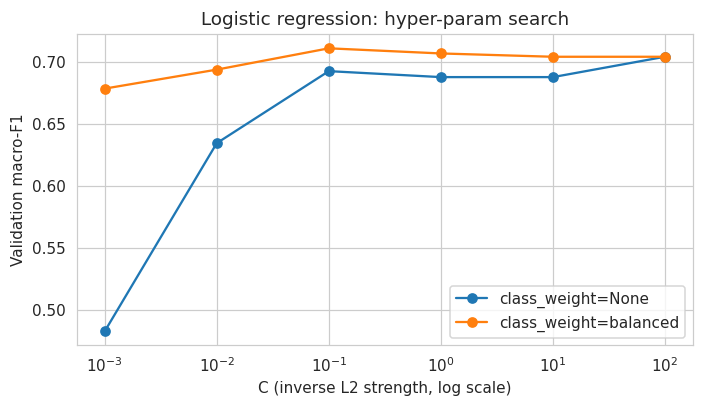

In [40]:
lr_results, lr_models = [], {}
for cw in [None, "balanced"]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        lr = LogisticRegression(penalty="l2", C=C, class_weight=cw, solver="lbfgs", max_iter=2000, random_state=SEED)
        lr.fit(X_train, y_train)                                   # Train on the training set
        m = evaluate(y_dev, lr.predict_proba(X_dev)[:, 1])         # Score on the validation set
        lr_results.append({"class_weight": str(cw), "C": C, **{f"val_{k}": v for k, v in m.items()}})
        lr_models[(str(cw), C)] = lr

lr_val = pd.DataFrame(lr_results)
display(lr_val.round(4))

# Model selection: Best validation macro-F1 (with AUC as tie breaker)
best_row = lr_val.sort_values(["val_macro_f1", "val_auc"], ascending=False).iloc[0]
best_lr_key = (best_row["class_weight"], best_row["C"])
best_lr = lr_models[best_lr_key]
print(f"\nSelected logistic regression: class_weight={best_lr_key[0]}, C={best_lr_key[1]}  "
      f"(Validation macro-F1 = {best_row['val_macro_f1']:.4f}, AUC = {best_row['val_auc']:.4f})")

# Visualize the search
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for cw, g in lr_val.groupby("class_weight"):
    ax.plot(g["C"], g["val_macro_f1"], marker="o", label=f"class_weight={cw}")
ax.set_xscale("log"); ax.set_xlabel("C (inverse L2 strength, log scale)"); ax.set_ylabel("Validation macro-F1")
ax.set_title("Logistic regression: hyper-param search"); ax.legend()
plt.tight_layout(); plt.show()

### 2b) Neural network
A fully-connected feedforward network (multi-layer perceptron, `sklearn.neural_network.MLPClassifier`): 128-d review embedding

Hidden layer(s) with **ReLU**

1 sigmoid output (probability of "positive") which is trained with the **Adam** optimizer along with (learning rate 0.001 in mini-batches of 64) to minimize the cross-entropy loss finally penalizing with L2 weight `alpha`.

In [41]:
def oversample_minority(X, y, seed=SEED):
    # Randomly duplicate minority-class (negative) rows until both classes have equal size
    rng = np.random.RandomState(seed)
    neg, pos = np.where(y == 0)[0], np.where(y == 1)[0]
    extra = rng.choice(neg, size=len(pos) - len(neg), replace=True)    # Extra negatives (with replacement)
    idx = np.concatenate([np.arange(len(y)), extra])
    return X[idx], y[idx]

def train_mlp(hidden, alpha, oversample, max_epochs=60, patience=10):
    # Train an MLP epoch by epoch; return (best model, per-epoch history DataFrame)
    Xtr, ytr = oversample_minority(X_train, y_train) if oversample else (X_train, y_train)
    clf = MLPClassifier(hidden_layer_sizes=hidden, activation="relu", solver="adam", alpha=alpha,
                        batch_size=64, learning_rate_init=1e-3, random_state=SEED)
    history, best, best_key, best_epoch = [], None, (-1, -1), 0
    for epoch in range(1, max_epochs + 1):
        clf.partial_fit(Xtr, ytr, classes=np.array([0, 1]))             # One pass over the training data
        p_dev = clf.predict_proba(X_dev)[:, 1]
        m = evaluate(y_dev, p_dev)
        history.append({"epoch": epoch, "train_loss": clf.loss_, "val_loss": log_loss(y_dev, p_dev),
                        "val_macro_f1": m["macro_f1"], "val_auc": m["auc"]})
        key = (m["macro_f1"], m["auc"])                                 # Selection criterion
        if key > best_key:                                              # New best epoch --> keep copy
            best, best_key, best_epoch = copy.deepcopy(clf), key, epoch
        if epoch - best_epoch >= patience:                              # Early stopping
            break
    return best, pd.DataFrame(history), best_epoch

nn_results, nn_models, nn_hist = [], {}, {}
for hidden in [(64,), (128, 64)]:
    for alpha in [1e-4, 1e-2]:
        for os_flag in [False, True]:
            model, hist, ep = train_mlp(hidden, alpha, os_flag)
            m = evaluate(y_dev, model.predict_proba(X_dev)[:, 1])
            key = (str(hidden), alpha, os_flag)
            nn_models[key], nn_hist[key] = model, hist
            nn_results.append({"hidden": str(hidden), "alpha": alpha, "oversample": os_flag, "best_epoch": ep,
                               **{f"val_{k}": v for k, v in m.items()}})

nn_val = pd.DataFrame(nn_results)
display(nn_val.round(4))

best_nn_row = nn_val.sort_values(["val_macro_f1", "val_auc"], ascending=False).iloc[0]
best_nn_key = (best_nn_row["hidden"], best_nn_row["alpha"], best_nn_row["oversample"])
best_nn = nn_models[best_nn_key]
print(f"\nSelected neural network: hidden={best_nn_key[0]}, alpha={best_nn_key[1]}, oversample={best_nn_key[2]}, "
      f"Best epoch={best_nn_row['best_epoch']}  (validation macro-F1 = {best_nn_row['val_macro_f1']:.4f}, AUC = {best_nn_row['val_auc']:.4f})")

,hidden,alpha,oversample,best_epoch,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_auc
0,"(64,)",0.0001,False,37,0.9539,0.9669,0.9843,0.9755,0.7913,0.9550
1,"(64,)",0.0001,True,20,0.9455,0.9708,0.9708,0.9708,0.7823,0.9539
2,"(64,)",0.0100,False,42,0.9539,0.9669,0.9843,0.9755,0.7913,0.9559
3,"(64,)",0.0100,True,21,0.9413,0.9707,0.9663,0.9685,0.7721,0.9558
4,"(128, 64)",0.0001,False,4,0.9560,0.9711,0.9820,0.9765,0.8103,0.9700
5,"(128, 64)",0.0001,True,7,0.9455,0.9687,0.9730,0.9709,0.7757,0.9603
6,"(128, 64)",0.0100,False,3,0.9560,0.9711,0.9820,0.9765,0.8103,0.9734
7,"(128, 64)",0.0100,True,3,0.9392,0.9749,0.9596,0.9672,0.7794,0.9616



Selected neural network: hidden=(128, 64), alpha=0.01, oversample=False, Best epoch=3  (validation macro-F1 = 0.8103, AUC = 0.9734)


Learning curves of the selected network: training loss and validation loss per epoch (left) and validation macro-F1 / AUC per epoch (right). The dashed line marks the epoch that was kept

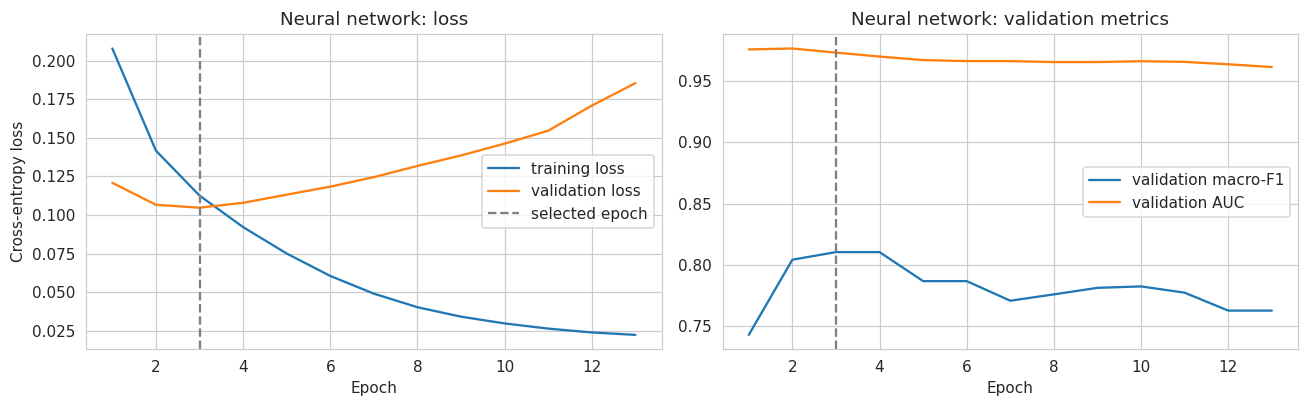

In [42]:
h = nn_hist[best_nn_key]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(h["epoch"], h["train_loss"], label="training loss")
axes[0].plot(h["epoch"], h["val_loss"], label="validation loss")
axes[0].axvline(best_nn_row["best_epoch"], color="gray", ls="--", label="selected epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss"); axes[0].set_title("Neural network: loss"); axes[0].legend()
axes[1].plot(h["epoch"], h["val_macro_f1"], label="validation macro-F1")
axes[1].plot(h["epoch"], h["val_auc"], label="validation AUC")
axes[1].axvline(best_nn_row["best_epoch"], color="gray", ls="--")
axes[1].set_xlabel("Epoch"); axes[1].set_title("Neural network: validation metrics"); axes[1].legend()
plt.tight_layout(); plt.show()

### 3a) Evaluation on the test set
The two selected models are now evaluated **once** on the untouched **test set**.

We report accuracy, precision, recall, F1 (+ve class), macro-F1 and AUC in a table, confusion matrix and ROC too.

In [43]:
p_test_lr = best_lr.predict_proba(X_test)[:, 1]
p_test_nn = best_nn.predict_proba(X_test)[:, 1]

res = pd.DataFrame({"Majority baseline (always +ve)": majority_baseline,
                    "Logistic regression (L2)": evaluate(y_test, p_test_lr),
                    "Neural network (MLP)": evaluate(y_test, p_test_nn)}).T
res.columns = ["Accuracy", "Precision (+ve)", "Recall (+ve)", "F1 (+ve)", "Macro-F1", "AUC"]
print(f"TEST SET RESULTS (n = {len(y_test)}; {int((y_test==0).sum())} negative, {int((y_test==1).sum())} positive)")
display(res.round(4))

for name, p in [("Logistic regression (L2)", p_test_lr), ("Neural network (MLP)", p_test_nn)]:
    print(f"\n===== {name}: per-class report =====")
    print(classification_report(y_test, (p >= 0.5).astype(int), target_names=["negative", "positive"], digits=4, zero_division=0))

TEST SET RESULTS (n = 478; 33 negative, 445 positive)


,Accuracy,Precision (+ve),Recall (+ve),F1 (+ve),Macro-F1,AUC
Majority baseline (always +ve),0.9310,0.9310,1.0000,0.9642,0.4821,0.5000
Logistic regression (L2),0.8808,0.9778,0.8921,0.9330,0.6951,0.9116
Neural network (MLP),0.9498,0.9647,0.9820,0.9733,0.7797,0.9053



===== Logistic regression (L2): per-class report =====
              precision    recall  f1-score   support

    negative     0.3333    0.7273    0.4571        33
    positive     0.9778    0.8921    0.9330       445

    accuracy                         0.8808       478
   macro avg     0.6556    0.8097    0.6951       478
weighted avg     0.9333    0.8808    0.9002       478


===== Neural network (MLP): per-class report =====
              precision    recall  f1-score   support

    negative     0.6800    0.5152    0.5862        33
    positive     0.9647    0.9820    0.9733       445

    accuracy                         0.9498       478
   macro avg     0.8223    0.7486    0.7797       478
weighted avg     0.9450    0.9498    0.9466       478



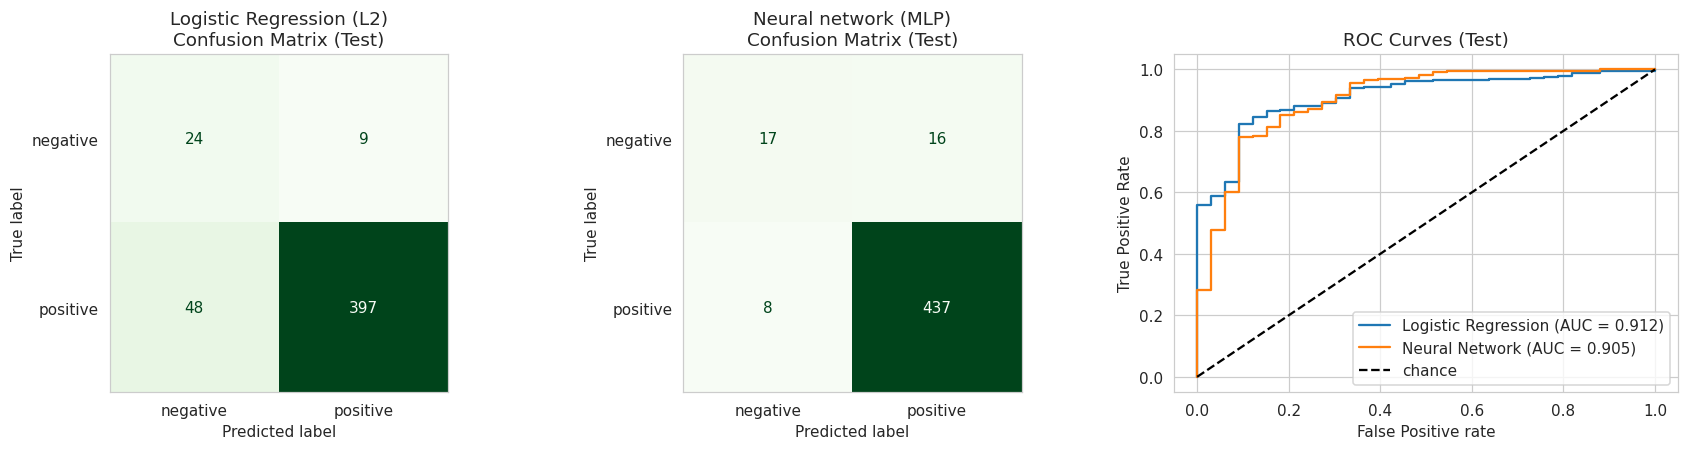

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Confusion matrices
for ax, (name, p) in zip(axes[:2], [("Logistic Regression (L2)", p_test_lr), ("Neural network (MLP)", p_test_nn)]):
    cm = confusion_matrix(y_test, (p >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(f"{name}\nConfusion Matrix (Test)"); ax.grid(False)

# ROC curves
for name, p in [("Logistic Regression", p_test_lr), ("Neural Network", p_test_nn)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[2].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", label="chance")
axes[2].set_xlabel("False Positive rate"); axes[2].set_ylabel("True Positive Rate"); axes[2].set_title("ROC Curves (Test)"); axes[2].legend()
plt.tight_layout(); plt.show()

### 3b) Discussion: comparison of the two models

### **Test-Set Results (n = 478: 33(-ve), 445(+ve)**

| Model | Accuracy | +ve F1 | Macro-F1 | AUC | -ve Precision / Recall |
|---|---:|---:|---:|---:|---:|
| Always +ve baseline | 0.931 | 0.964 | 0.482 | 0.500 | – / 0.000 |
| Logistic regression (L2, balanced, C = 0.1) | 0.881 | 0.933 | 0.695 | **0.912** | 0.333 / **0.727** |
| Neural network (128–64, early stopping at epoch 3) | **0.948** | **0.972** | **0.774** | 0.905 | **0.654** / 0.515 |

### **Discussion**

* The neural network achieves the highest **accuracy (0.948)** and **macro-F1 (0.774)**, while logistic regression performs worse than the always positive baseline in accuracy (0.881 vs. 0.931)
* Logistic regression detects more negative reviews (**recall = 0.727**) but produces more false positives (precision = 0.333). The neural network is more precise (0.654) but misses more negative reviews (recall = 0.515).
* Both models have similar AUC scores (0.912 vs. 0.905), suggesting that their differences at the 0.5 threshold largely reflect **classification decisions rather than ranking ability**
* Both models use averaged GloVe embeddings, which lose word order and negation information. Removing *not* and *no* further limits sentiment detection. The neural network also overfits quickly, making early stopping at epoch 3 important.
* Validation AUCs (0.948 for logistic regression and 0.973 for the neural network) are higher than test AUCs (0.912 and 0.905). The small validation set and selection among multiple configurations may contribute to this gap. Since results come from a single split and seed, the differences are **indicative rather than conclusive**.

**Possible improvements:** Retain negation words, use TF-IDF-weighted embeddings, apply cross-validation, tune the classification threshold, and explore domain-specific embeddings.

# Task 3: Self-reflection

| Question | Answer (provide the answer index) |
|---|---|
| **Q1:** Rate your performance | **5** |
| **Q2:** How much does your understanding of the concepts influence your performance? | **5** |
| **Q3:** How much does the design of the examples/questions influence your performance? | **4** |
| **Q4:** Primary factors influencing the relatability of the examples | **7** |

**Comments / suggestions about Homework 1 (optional):** The homework helped me understand the concepts through practical implementation. More relatable examples and clearer explanations of model evaluation would make the learning experience even better.

# References and resources used
* Lecture slides: *Introduction*, *Vector Semantics*, co-occurrence matrices, SVD, GloVe, logistic regression, evaluation, *100 Days of Machine Learning(CampuX)* for understanding Machine Learning in depth.


* `load_embedding_model()` and `get_matrix_of_vectors()` are taken from the assignment handout (the latter lightly adapted as stated in its description).
* **Generative-AI disclosure:** Used ChatGPT for proof-reading and drafting the observations. Also I used claude for the specifically understanding the final Evaluation part thoroughly.